# RT
Load RT data and clean it step by step.

In [1]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")


def load_rt_data() -> tuple[pd.DataFrame, Path]:
    project_root = resolve_project_root()
    rt_file = project_root / "data" / "raw" / "Alternative Medien" / "RT_de.xlsx"

    frame = pd.read_excel(rt_file)
    frame["source"] = "RT_de"
    frame["source_file"] = rt_file.name
    return frame, rt_file


df, rt_file = load_rt_data()
df_clean = df.copy()


In [2]:
df_clean = df_clean.drop(columns=["Full_Text"], errors="ignore")
df_clean

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in ...",Die Nordatlantikallianz habe Dänemark 20 Jahre...,"Dänemark sei seit 20 Jahren nicht in der Lage,...",https://freedert.online/international/267662-t...,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in ...,Bei einem schweren Zugunglück nahe Córdoba ent...,Bei einem schweren Zugunglück im Süden Spanien...,https://freedert.online/europa/267660-mindeste...,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen...,Der für Anfang der Woche angekündigte Besuch d...,Bundeskanzler Friedrich Merz wird am morgigen ...,https://freedert.online/der-nahe-osten/267652-...,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das...,"Die größte US-Delegation aller Zeiten, massive...",Das World Economic Forum 2026 steht unter eine...,https://freedert.online/schweiz/267655-davos-w...,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen...,Europa hat Russlands Rolle verkannt und zahlt ...,Von Kirill Strelnikow\n\nDie Europäer waren se...,https://freedert.online/meinung/267625-welch-e...,RT_de,RT_de.xlsx
...,...,...,...,...,...,...,...,...
12385,2024-11-14,Hauptseite\n/\nSchweiz,Gedemütigt und geschlagen: Was Prostituierte i...,Die Realität von Sexarbeiterinnen in der Schwe...,Eine aktuelle Studie der Schweizer Organisatio...,https://freedert.online/schweiz/225947-geschla...,RT_de,RT_de.xlsx
12386,2024-11-14,Hauptseite\n/\nUkraine-Krieg,Bloomberg: Ukrainer spenden immer weniger für ...,"Ukrainische Stiftungen, die die Armee unterstü...","Die Bereitschaft der Ukrainer, zur Verteidigun...",https://freedert.online/europa/225884-bloomber...,RT_de,RT_de.xlsx
12387,2024-11-14,Hauptseite\n/\nÖsterreich,Österreich: Traditionsmarke Kika/Leiner vor de...,Ein bitteres Ende für den österreichischen Möb...,Die österreichische Möbelhauskette Kika/Leiner...,https://freedert.online/oesterreich/225899-oes...,RT_de,RT_de.xlsx
12388,2024-11-14,Hauptseite\n/\nDeutschland,Sachsen: CDU und SPD wollen jetzt allein koali...,Am 1. September waren die Landtagswahlen in Sa...,Nachdem die Verhandlungen mit dem BSW geplatzt...,https://freedert.online/inland/225976-sachsen-...,RT_de,RT_de.xlsx


In [3]:
from IPython.display import display

pd.set_option("display.max_colwidth", 160)

def clean_rt_text_column(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    cleaned["Text"] = (
        cleaned["Text"]
        .astype("string")
        .fillna("")
        .str.replace(r"(?s)\n*\s*Mehr zum Thema.*$", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return cleaned


df_clean = clean_rt_text_column(df_clean)

print(f"Loaded {len(df_clean):,} rows from {rt_file}")


Loaded 12,390 rows from /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/RT_de.xlsx


In [4]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing


,missing_count,missing_pct
Summary,14,0.112994
Date,0,0.000000
Category,0,0.000000
Title,0,0.000000
Text,0,0.000000
URL,0,0.000000
source,0,0.000000
source_file,0,0.000000


In [5]:
# filter df_clean to Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"

df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = df_clean["Date"].between(start, end, inclusive="both")

df_clean = df_clean.loc[mask].copy()



In [6]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4570 entries, 0 to 4569
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4570 non-null   datetime64[us]
 1   Category     4570 non-null   str           
 2   Title        4570 non-null   str           
 3   Summary      4567 non-null   str           
 4   Text         4570 non-null   string        
 5   URL          4570 non-null   str           
 6   source       4570 non-null   str           
 7   source_file  4570 non-null   str           
dtypes: datetime64[us](1), str(6), string(1)
memory usage: 285.8 KB


In [7]:
# Text column already created in the dedicated cleaning cell
df_clean["Text"] = df_clean["Text"].astype("string")


Removal of "Mehr zum Thema"

In [8]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Text"] = df_clean["Text"].apply(remove_mehr_zum_thema)


In [9]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [10]:
#!pip install seaborn


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    4570.0
mean      582.3
std       410.2
min         0.0
10%       249.9
25%       313.0
50%       421.0
75%       709.8
90%      1208.1
95%      1450.6
99%      1958.0
max      3867.0
Name: article_length_words, dtype: float64

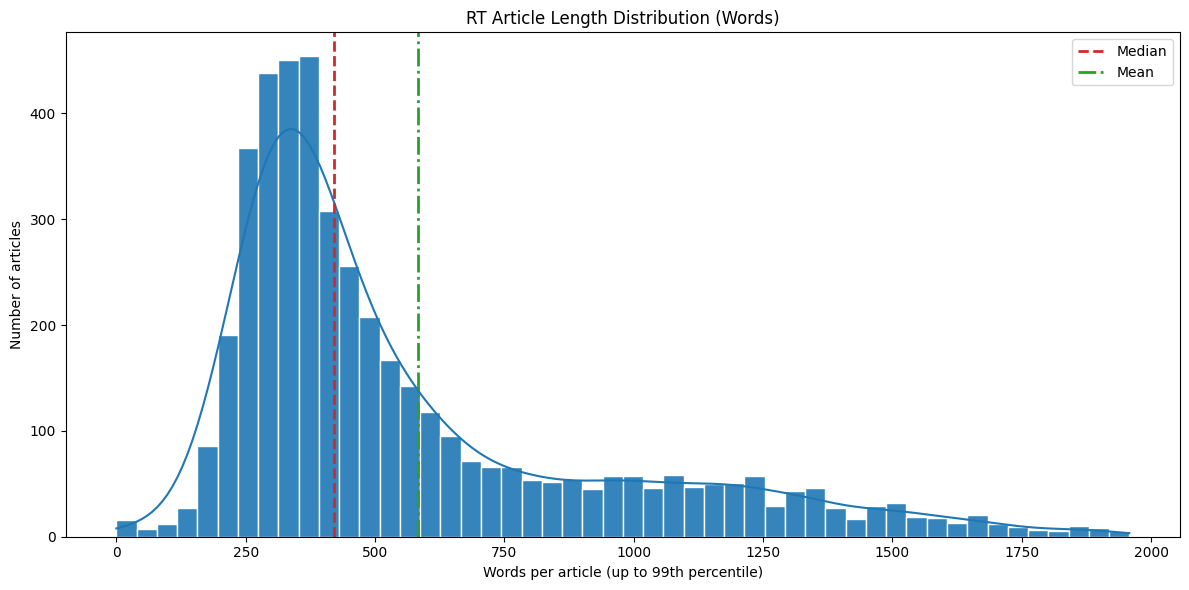

In [13]:
# Plot article length distribution, excluding extreme outliers above the 99th percentile
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
# Compute daily article counts and 7-day rolling average
daily_counts = (
    df_clean.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()


,Date,articles,rolling_7d
0,2025-08-01,15,15.000000
1,2025-08-02,28,21.500000
2,2025-08-03,24,22.333333
3,2025-08-04,26,23.250000
4,2025-08-05,32,25.000000


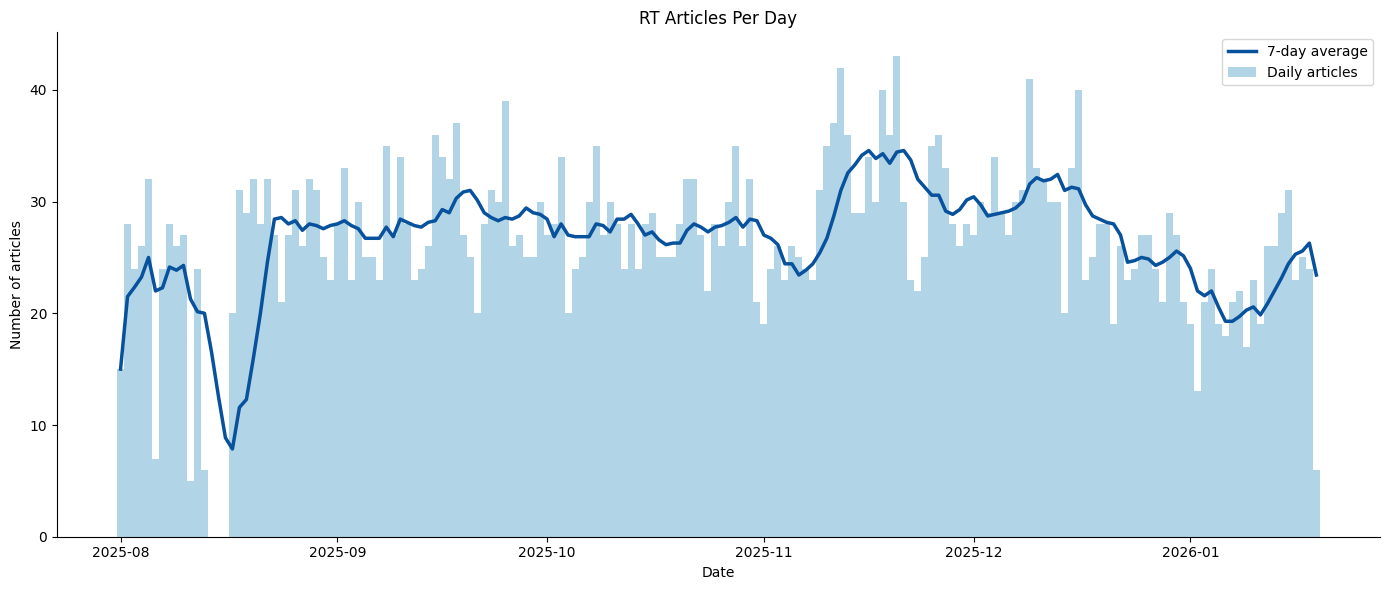

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## BERTopic old 


In [16]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [17]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4570 entries, 0 to 4569
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  4570 non-null   datetime64[us]
 1   Category              4570 non-null   str           
 2   Title                 4570 non-null   str           
 3   Summary               4567 non-null   str           
 4   Text                  4570 non-null   str           
 5   URL                   4570 non-null   str           
 6   source                4570 non-null   str           
 7   source_file           4570 non-null   str           
 8   article_length_words  4570 non-null   int64         
 9   article_length_chars  4570 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(7)
memory usage: 357.2 KB


In [19]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)


2 0.9


In [20]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)


cwd: /Users/MattisHaumann/Dev/Thesis/data preprocessing
project root added: /Users/MattisHaumann/Dev/Thesis


In [21]:
# from BERTopic.bertopic_pipeline import prepare_documents
# from BERTopic.bertopic_config import BERTopicConfig, title_config

# cfg = BERTopicConfig(min_df=5, max_df=0.88)   # or whatever you test
# prep = prepare_documents(df_clean, text_col="Text", config=cfg, id_col="URL")
# n = len(prep)

# print("prepared docs:", n)
# print("min_df:", cfg.min_df, "max_df:", cfg.max_df)
# print("max_df_docs:", int(cfg.max_df * n) if isinstance(cfg.max_df, float) else cfg.max_df)


In [22]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 13:11:57,602 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-10 13:12:19,300 - BERTopic - Embedding - Completed ✓
2026-03-10 13:12:19,300 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 13:12:31,108 - BERTopic - Dimensionality - Completed ✓
2026-03-10 13:12:31,111 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 13:12:31,181 - BERTopic - Cluster - Completed ✓
2026-03-10 13:12:31,186 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 13:12:33,286 - BERTopic - Representation - Completed ✓


In [23]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1648,-1_nato_europäischen_euro_china,"[nato, europäischen, euro, china, ukrainische, selenskij, soldaten, polen, sanktionen, europäische]","[Von Dagmar Henn Ja, da bin ich auch für. ""Die zentrale Rolle der Europäischen Union bei der Sicherung des Friedens für die Ukraine muss sich voll und ganz ..."
1,0,321,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
2,1,265,1_selenskij_trumps_wladimir putin_nato,"[selenskij, trumps, wladimir putin, nato, sanktionen, beziehungen, witkoff, alaska, gespräche, präsident donald]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
3,2,255,2_afd_partei_spd_cdu,"[afd, partei, spd, cdu, bsw, grünen, stimmen, merz, wahl, weidel]",[Bei der konstituierenden Ratssitzung im nordrhein-westfälischen Gelsenkirchen am Mittwoch dieser Woche stand nach der Vereidigung von Oberbürgermeisterin A...
4,3,220,3_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
5,4,127,4_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, xi, chinesische, chinesischen, japan, zölle, beziehungen]","[Der chinesische Präsident Xi Jinping, der wiederholt erklärt hat, dass die Wiedervereinigung mit Taiwan ""unvermeidlich"" sei, bekräftigte diese Ansicht in s..."
6,5,121,5_drohnen_flugzeuge_nato_flugzeug,"[drohnen, flugzeuge, nato, flugzeug, polen, luftraum, drohne, polnischen, vorfall, ukrainische]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
7,6,112,6_nato_estland_russen_estnischen,"[nato, estland, russen, estnischen, finnland, europäischen, kallas, grenze, bip, europäische]","[Von Rainer Rupp Estland erinnert an ein Chihuahua-Hündchen, das für seine NATO-Herrchen Moskau hysterisch anbellt und sich stark genug fühlt, unter EU/NATO..."
8,7,110,7_polizei_verletzt_berlin_täter,"[polizei, verletzt, berlin, täter, ermittlungen, jährige, brand, personen, feuerwehr, verletzten]",[In Deutschland gab es auch in der diesjährigen Silvesternacht – fast schon traditionell – eine Vielzahl von Vorfällen. Leider sind wieder Tote und Verletzt...
9,8,101,8_vermögenswerte_euro_milliarden euro_belgien,"[vermögenswerte, euro, milliarden euro, belgien, euroclear, gelder, eingefrorenen, kommission, wever, de wever]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."


In [24]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [25]:
import sys
!{sys.executable} -m pip install "scipy<1.13" "gensim==4.3.2"


In [26]:
print(run_bertopic_pipeline.__module__)


BERTopic.bertopic_pipeline


In [27]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.0918327768241486,
 'topic_diversity': 0.84,
 'num_topics': 40,
 'top_k': 10}

TO DO for tomorrow

In [28]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=10),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 13:13:00,215 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-10 13:13:20,985 - BERTopic - Embedding - Completed ✓
2026-03-10 13:13:20,986 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 13:13:26,207 - BERTopic - Dimensionality - Completed ✓
2026-03-10 13:13:26,212 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 13:13:26,280 - BERTopic - Cluster - Completed ✓
2026-03-10 13:13:26,290 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 13:13:28,543 - BERTopic - Representation - Completed ✓


In [29]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1787,-1_nato_ukrainischen_afd_deutschen,"[nato, ukrainischen, afd, deutschen, europäischen, putin, kiew, ukrainische, deutsche, euro]",[Von Tarik Cyril Amar Bundeskanzler Friedrich Merz hat für Aufsehen in den Medien gesorgt und innerhalb seiner eigenen Regierungskoalition mit den Sozialdem...
1,0,321,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
2,1,236,1_putin_treffen_selenskij_präsidenten,"[putin, treffen, selenskij, präsidenten, wladimir, trumps, us präsident, donald trump, washington, wladimir putin]","[US-Präsident Donald Trump hat sich für die Organisation eines dreiseitigen Gipfels mit Wladimir Putin und Wladimir Selenskij ausgesprochen, um die Ukraine-..."
3,2,177,2_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venezolanischen, venezolanische, caracas, nicolás, nicolás maduro, machado]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
4,3,112,3_nato_putin_estland_russen,"[nato, putin, estland, russen, estnischen, finnland, europäischen, länder, westlichen, kallas]","[Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wladimir Wladimirowitsch Putin auf der jüngsten Sitzung des Sicherheitsrats des Landes machte, kö..."
5,4,111,4_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, japan, xi, zölle, takaichi]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
6,5,101,5_vermögenswerte_milliarden_milliarden euro_euro,"[vermögenswerte, milliarden, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, geld, kommission]",[Von Anastassija Kulikowa Die Europäische Union hat die Entscheidung über die Verwendung der eingefrorenen russischen Vermögenswerte zur Unterstützung der U...
7,6,96,6_drohnen_luftraum_nato_polen,"[drohnen, luftraum, nato, polen, drohne, flugzeuge, polnischen, vorfall, ukrainische, flughafen]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
8,7,70,7_orbán_ungarn_brüssel_serbien,"[orbán, ungarn, brüssel, serbien, ungarische, union, viktor, beitritt, moldawien, viktor orbán]","[""Ja zur EU-Mitgliedschaft Serbiens. Nein zur EU-Mitgliedschaft der Ukraine"", erklärte der ungarische Außenminister Péter Szijjártó am Donnerstag auf X. In ..."
9,8,69,8_selenskij_kiew_ukrainischen_putin,"[selenskij, kiew, ukrainischen, putin, wladimir, konflikts, treffen, friedensplan, plan, ukrainische]",[Von Geworg Mirsajan Der russisch-ukrainische Gipfel sollte nach Ansicht von US-Präsident Donald Trump die nächste Etappe des Friedensprozesses im Ukraine-K...


In [30]:
# pip install gensim
def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.07707757721222794,
 'topic_diversity': 0.7785714285714286,
 'num_topics': 70,
 'top_k': 10}

In [31]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 13:13:52,444 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-10 13:14:12,982 - BERTopic - Embedding - Completed ✓
2026-03-10 13:14:12,983 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 13:14:18,166 - BERTopic - Dimensionality - Completed ✓
2026-03-10 13:14:18,166 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 13:14:18,229 - BERTopic - Cluster - Completed ✓
2026-03-10 13:14:18,231 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 13:14:20,547 - BERTopic - Representation - Completed ✓


In [32]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1863,-1_ukrainischen_nato_afd_europäischen,"[ukrainischen, nato, afd, europäischen, putin, euro, kiew, deutsche, ukrainische, selenskij]","[Von Dagmar Henn Teil l Die norwegische Studie ""Europes Choice"" (Europas Wahl) lieferte nach ihrem Erscheinen auf Englisch zahlreiche Schlagzeilen in Deutsc..."
1,0,321,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
2,1,236,1_putin_selenskij_wladimir_trumps,"[putin, selenskij, wladimir, trumps, us präsident, donald trump, washington, wladimir putin, kiew, verhandlungen]","[US-Präsident Donald Trump hat sich für die Organisation eines dreiseitigen Gipfels mit Wladimir Putin und Wladimir Selenskij ausgesprochen, um die Ukraine-..."
3,2,177,2_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venezolanischen, venezolanische, caracas, nicolás maduro, nicolás, machado]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
4,3,127,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, xi, chinesische, chinesischen, japan, zölle, beziehungen]","[Der chinesische Präsident Xi Jinping, der wiederholt erklärt hat, dass die Wiedervereinigung mit Taiwan ""unvermeidlich"" sei, bekräftigte diese Ansicht in s..."
5,4,121,4_drohnen_flugzeuge_flugzeug_nato,"[drohnen, flugzeuge, flugzeug, nato, luftraum, polen, drohne, polnischen, vorfall, ukrainische]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
6,5,112,5_nato_putin_estland_russen,"[nato, putin, estland, russen, estnischen, finnland, europäischen, kallas, konflikt, grenze]",[Von Murad Sadygsade Im Laufe des Jahres 2025 glich Moskaus Kurs in der russischen Nahostpolitik einer systematischen Feinabstimmung bestehender Kanäle. Daz...
7,6,101,6_vermögenswerte_milliarden_milliarden euro_euro,"[vermögenswerte, milliarden, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, geld, kommission]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...
8,7,70,7_orbán_ungarn_brüssel_serbien,"[orbán, ungarn, brüssel, serbien, ungarische, union, viktor, beitritt, moldawien, europäischen]","[""Ja zur EU-Mitgliedschaft Serbiens. Nein zur EU-Mitgliedschaft der Ukraine"", erklärte der ungarische Außenminister Péter Szijjártó am Donnerstag auf X. In ..."
9,8,69,8_selenskij_kiew_ukrainischen_putin,"[selenskij, kiew, ukrainischen, putin, wladimir, konflikts, plan, friedensplan, nato, ukrainische]","[Matthew Whitaker, der ständige Vertreter der USA bei der NATO, hat erklärt, die Ukraine müsse sich auf eine Fortsetzung der Kampfhandlungen im Jahr 2026 vo..."


In [33]:
!pip install gensim
def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.08351607505495334,
 'topic_diversity': 0.7763636363636364,
 'num_topics': 55,
 'top_k': 10}

In [34]:
# Resolve doc_info from the currently active BERTopic result if needed.
if "doc_info" not in globals():
    candidate_results = [
        globals().get("result"),
        globals().get("result_full_text"),
        globals().get("result_full_text_v2"),
        globals().get("result_title"),
        globals().get("result_title_v2"),
    ]

    for candidate in candidate_results:
        if isinstance(candidate, dict) and "doc_info" in candidate:
            doc_info = candidate["doc_info"]
            break

if "doc_info" not in globals():
    raise NameError("doc_info is not defined. Run a BERTopic result cell first.")

merge_cols = ["original_index", "Topic", "Name"]
if "Probability" in doc_info.columns:
    merge_cols.append("Probability")

rt_topics = df_clean.reset_index().merge(
    doc_info[merge_cols],
    left_on="index",
    right_on="original_index",
    how="left",
)

rt_topics.head()

,index,Date,Category,Title,Summary,Text,URL,source,source_file,article_length_words,article_length_chars,original_index,Topic,Name,Probability
0,0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx,280,1979,0.0,18.0,18_grönland_dänemark_grönlands_insel,1.000000
1,1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx,423,3091,1.0,52.0,52_crans_montana_crans montana_bar,1.000000
2,2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx,418,3211,2.0,22.0,22_merz_bundeskanzler_kanzler_friedrich merz,0.980528
3,3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx,329,2534,3.0,-1.0,-1_ukrainischen_nato_afd_europäischen,0.000000
4,4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx,965,6979,4.0,-1.0,-1_ukrainischen_nato_afd_europäischen,0.000000


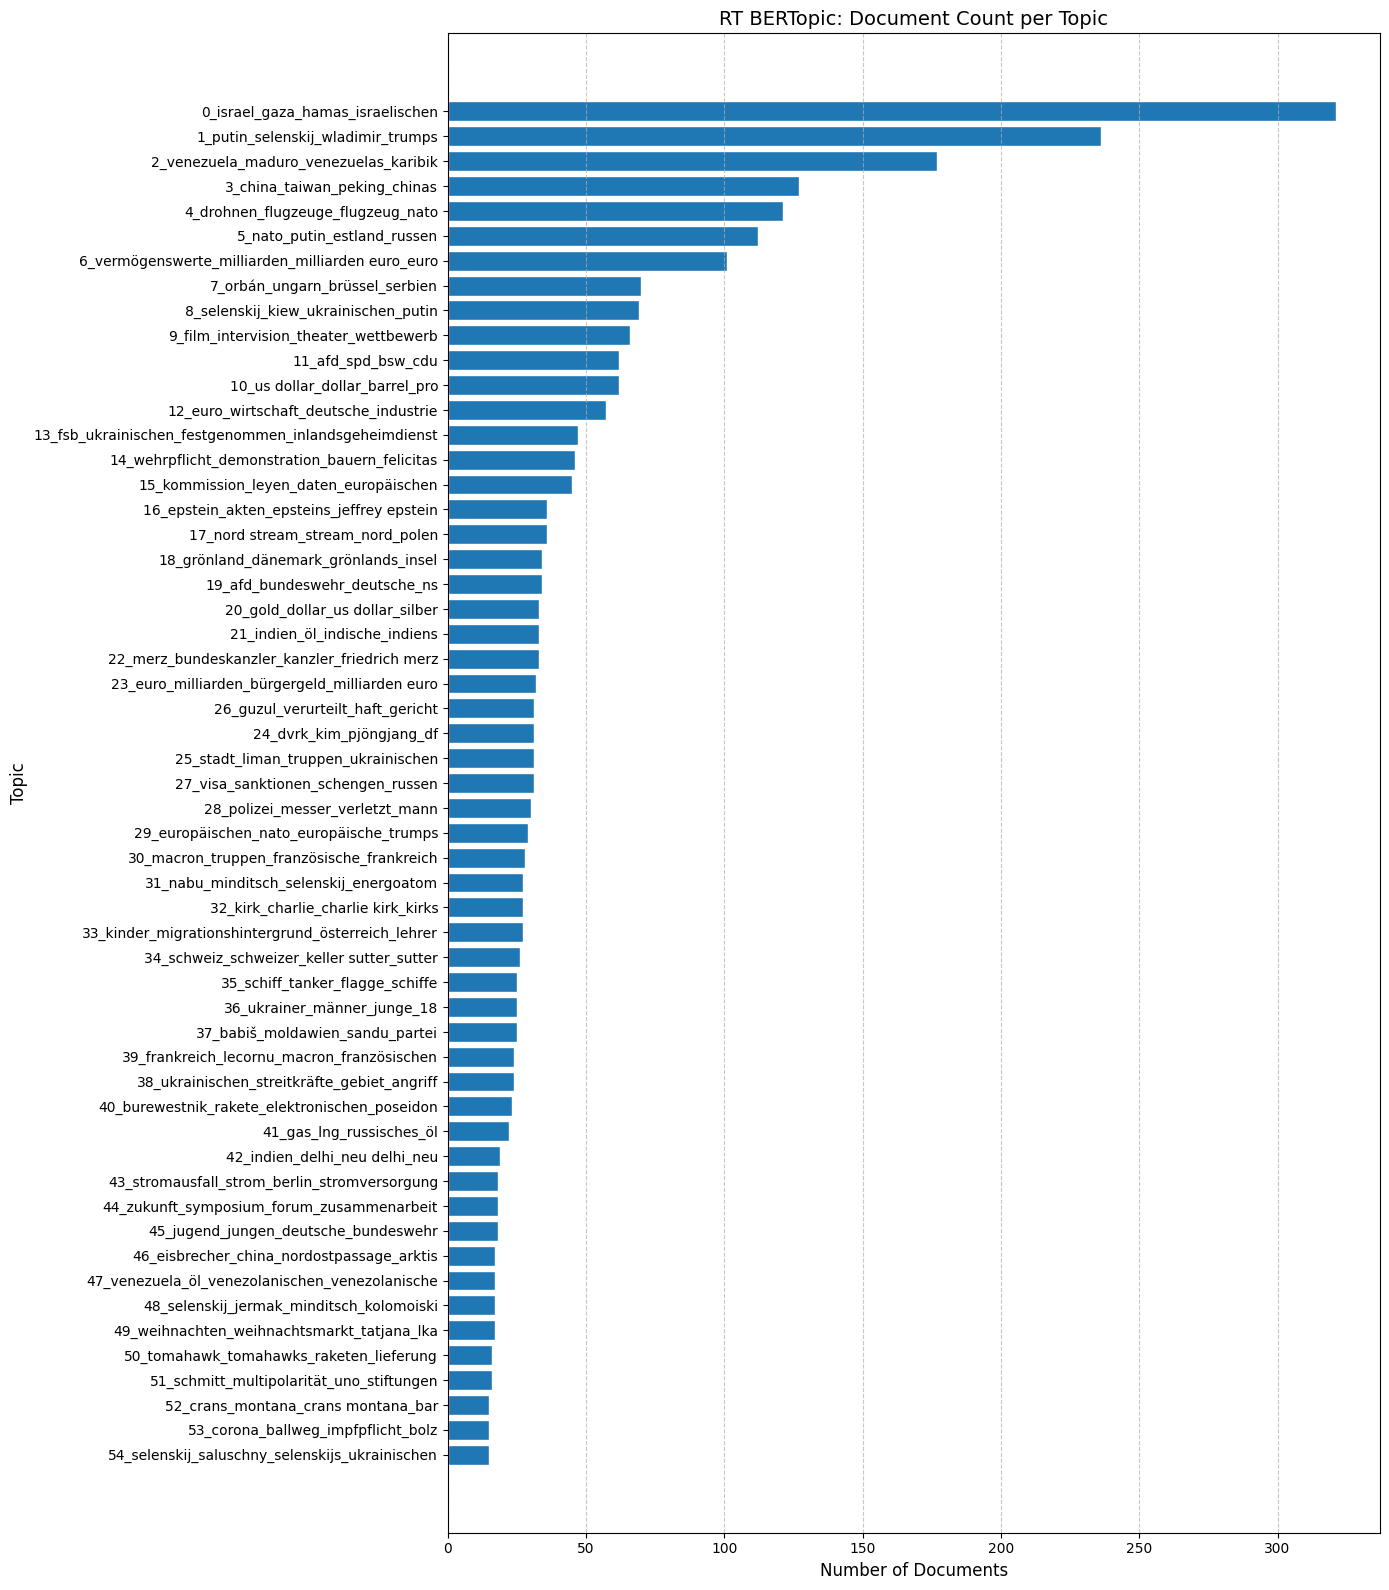

In [35]:
fig, ax = plt.subplots(figsize=(14, 16))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('RT BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:12,  2.08s/it]


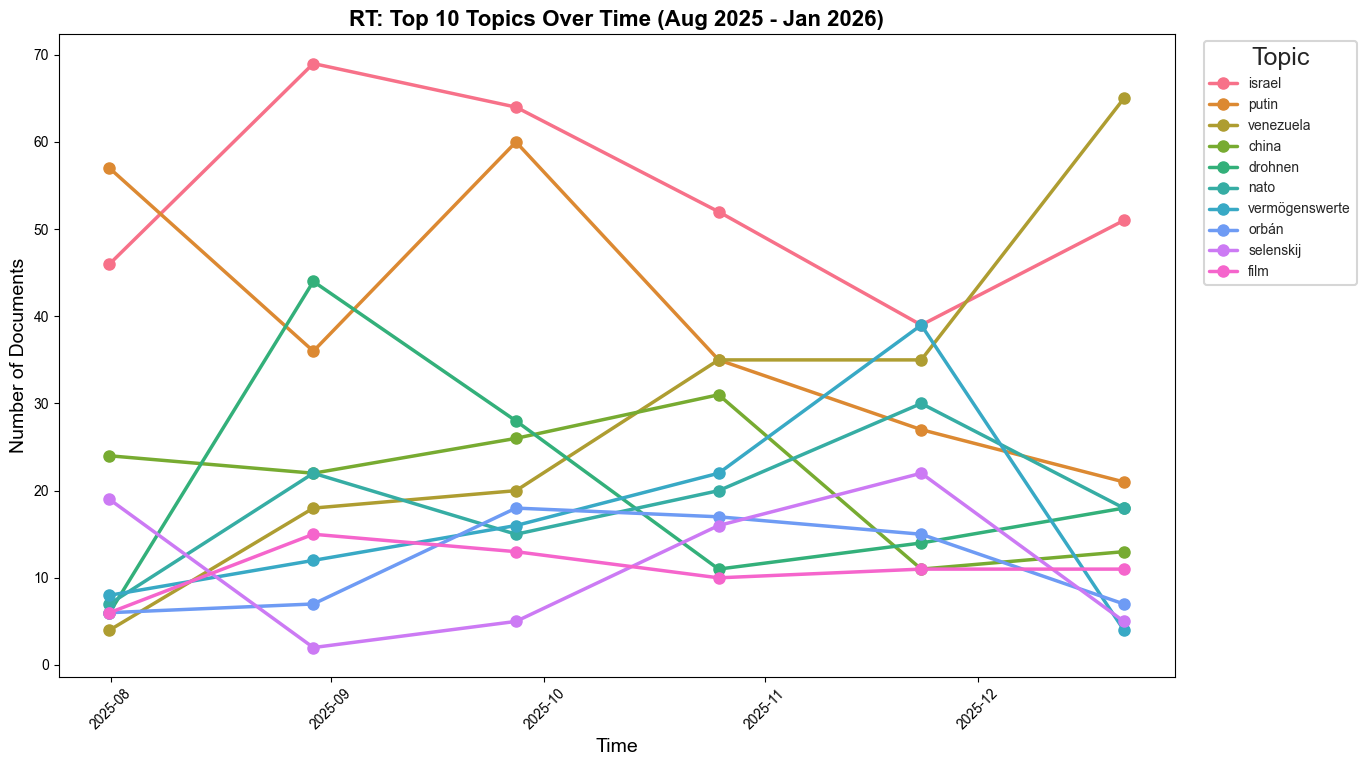

In [36]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('RT: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# # Final BERTopic comparison table: all topics + representative words
# from IPython.display import display

# topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

# def _representative_words_for_topic(topic_id: int) -> str:
#     terms = result["topic_model"].get_topic(int(topic_id)) or []
#     return ", ".join(word for word, _ in terms)

# topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
# topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

# with pd.option_context("display.max_colwidth", None, "display.width", 220):
#     display(topics_comparison_df)


In [38]:
# # BERTopic v2 run: full text first, then title-only
# from BERTopic.bertopic_pipelinev2 import (
#     BERTopicV2Config,
#     BERTopicV2ConfigTitle,
#     run_bertopic_pipeline,
# )

# result_full_text_v2 = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Full_Text",
#     config=BERTopicV2Config(),
#     id_col="URL",
#     source_name="RT_de",
# )

# result_title_v2 = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Title",
#     config=BERTopicV2ConfigTitle(),
#     id_col="URL",
#     source_name="RT_de",
# )

# print(
#     f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
#     f"v2 title docs: {len(result_title_v2['docs']):,}"
# )



## BERTopic V2 Title

In [ ]:
result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=BERTopicV2ConfigTitle(),
    id_col="URL",
    source_name="RT_de",
)

print(
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)
